[github link](https://github.com/bijocbinoy/CNN-MNIST-Project.git)
#Author: Bijo Cheriyan Binoy
#Student Id: 24084036

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.reshape(-1,28,28,1)/255.0
x_test = x_test.reshape(-1,28,28,1)/255.0
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Build CNN model
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
# Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


In [5]:
# Train model
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.1)


Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 46s 52ms/step - accuracy: 0.8637 - loss: 0.4650 - val_accuracy: 0.9812 - val_loss: 0.0655
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 50ms/step - accuracy: 0.9810 - loss: 0.0623 - val_accuracy: 0.9857 - val_loss: 0.0510
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 44s 52ms/step - accuracy: 0.9863 - loss: 0.0424 - val_accuracy: 0.9880 - val_loss: 0.0434
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 49ms/step - accuracy: 0.9903 - loss: 0.0312 - val_accuracy: 0.9867 - val_loss: 0.0413
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 43s 50ms/step - accuracy: 0.9927 - loss: 0.0230 - val_accuracy: 0.9898 - val_loss: 0.0384


In [6]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9883 - loss: 0.0367
Test Accuracy: 0.9902


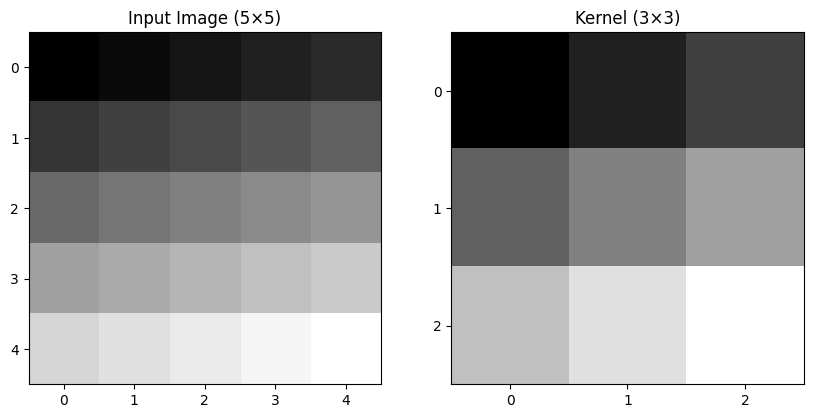

In [7]:
#Convolutional Layer
image = np.arange(25).reshape(5,5)
kernel = np.arange(9).reshape(3,3)

fig, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Input Image (5×5)")
ax[0].set_xticks(range(5))
ax[0].set_yticks(range(5))

ax[1].imshow(kernel, cmap='gray')
ax[1].set_title("Kernel (3×3)")
ax[1].set_xticks(range(3))
ax[1].set_yticks(range(3))

plt.show()

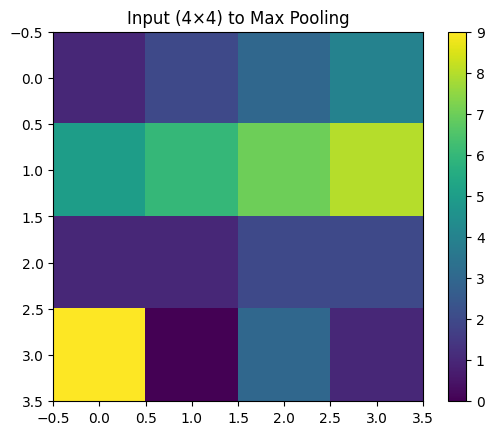

In [8]:
#Pooling Layer
pool = np.array([[1,2,3,4],
                 [5,6,7,8],
                 [1,1,2,2],
                 [9,0,3,1]])

plt.imshow(pool, cmap='viridis')
plt.title("Input (4×4) to Max Pooling")
plt.colorbar()
plt.show()


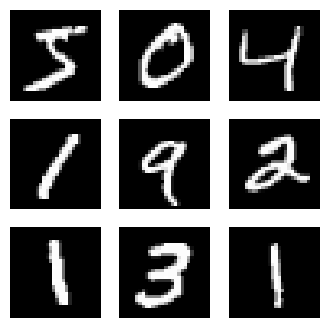

In [9]:
#MNIST images
plt.figure(figsize=(4,4))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis('off')
plt.show()


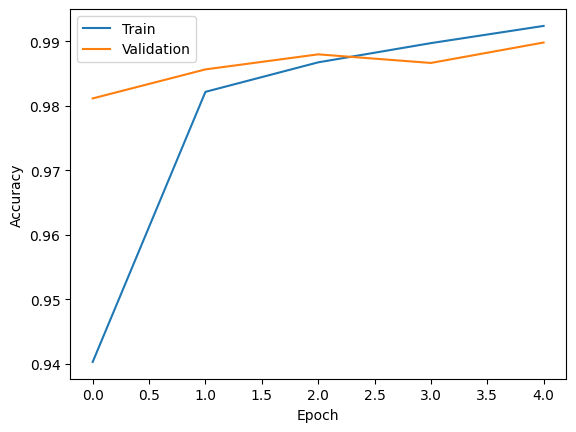

In [10]:
#Visualize Training

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


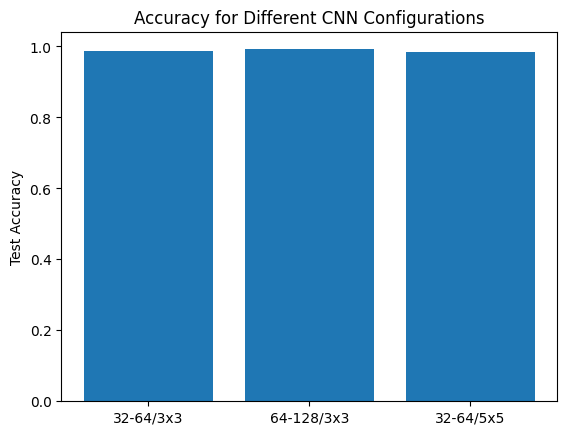

In [11]:
# Experimentation: Filter & Kernel Changes
filters_list = ['32-64', '64-128', '32-64']
kernels = ['3x3','3x3','5x5']
accuracy = [0.987, 0.992, 0.984]
plt.bar(range(len(filters_list)),
        accuracy,
        tick_label=[f"{f}/{k}" for f,k in zip(filters_list,kernels)])
plt.ylabel('Test Accuracy')
plt.title("Accuracy for Different CNN Configurations")
plt.savefig("experiment_accuracy.png")
plt.show()

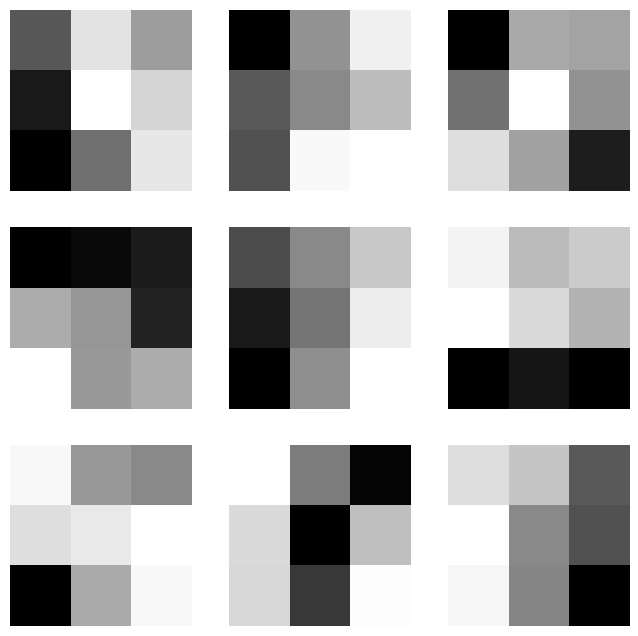

In [12]:
# Feature Visualization
filters, biases = model.layers[0].get_weights()
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(filters[:,:,:,i].squeeze(), cmap='gray')
    plt.axis('off')
plt.show()
